# Random Forest para Detecção de Alzheimer

## Objetivo
Este notebook implementa um **classificador Random Forest (Floresta Aleatória)** otimizado para classificação binária, com o objetivo de determinar se um paciente tem Alzheimer ou não.

## Sobre Random Forest
O Random Forest é um algoritmo de **ensemble** que combina múltiplas Árvores de Decisão para criar um modelo mais robusto e preciso. Cada árvore é treinada com uma amostra diferente dos dados (bootstrap) e considera apenas um subconjunto aleatório de features.

### Características do Random Forest:
- **Ensemble Method**: Combina múltiplas árvores (bagging)
- **Reduz Overfitting**: A média de várias árvores é mais estável
- **Robustez**: Menos sensível a outliers e ruído
- **Importância de Features**: Mede a contribuição de cada variável
- **Paralelizável**: Árvores podem ser treinadas em paralelo

## Métricas Importantes para Diagnóstico Médico
- **Recall (Sensibilidade)**: Capacidade de identificar corretamente os casos positivos
- **Precisão**: Proporção de diagnósticos positivos corretos
- **F1-Score**: Média harmônica entre precisão e recall
- **AUC-ROC**: Área sob a curva ROC

## 1. Importação das Bibliotecas

In [1]:
# ==============================================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier  # Random Forest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [2]:
# ==============================================================================
# CARREGAMENTO DOS DADOS
# ==============================================================================

import os

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    csv_path = '/content/drive/MyDrive/alzheimers_disease_data.csv'
    print('Rodando no Google Colab')
except ImportError:
    print('Rodando localmente - Selecione o arquivo CSV')
    import tkinter as tk
    from tkinter import filedialog
    
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    csv_path = filedialog.askopenfilename(
        title='Selecione o arquivo alzheimers_disease_data.csv',
        filetypes=[('CSV files', '*.csv'), ('All files', '*.*')]
    )
    root.destroy()
    
    if not csv_path:
        raise FileNotFoundError('Nenhum arquivo selecionado!')

df = pd.read_csv(csv_path)

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} amostras x {df.shape[1]} features')

Rodando localmente - Selecione o arquivo CSV
Dataset carregado com sucesso!
Dimensões: 2149 amostras x 35 features


In [3]:
# ==============================================================================
# EXPLORAÇÃO INICIAL
# ==============================================================================

print("=" * 60)
print("PRIMEIRAS LINHAS DO DATASET")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(df.info())

PRIMEIRAS LINHAS DO DATASET


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid



INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non

## 3. Pré-processamento dos Dados

In [4]:
# ==============================================================================
# PRÉ-PROCESSAMENTO
# ==============================================================================

colunas_remover = ['PatientID', 'DoctorInCharge']
df = df.drop(columns=colunas_remover)
print(f"Colunas removidas: {colunas_remover}")
print(f"Novas dimensões: {df.shape}")

print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Duplicatas: {df.duplicated().sum()}")

Colunas removidas: ['PatientID', 'DoctorInCharge']
Novas dimensões: (2149, 33)

Valores nulos: 0
Duplicatas: 0


## 4. Análise da Variável Alvo

Distribuição da variável alvo:
  - Saudável (0): 1389 (64.6%)
  - Com Alzheimer (1): 760 (35.4%)


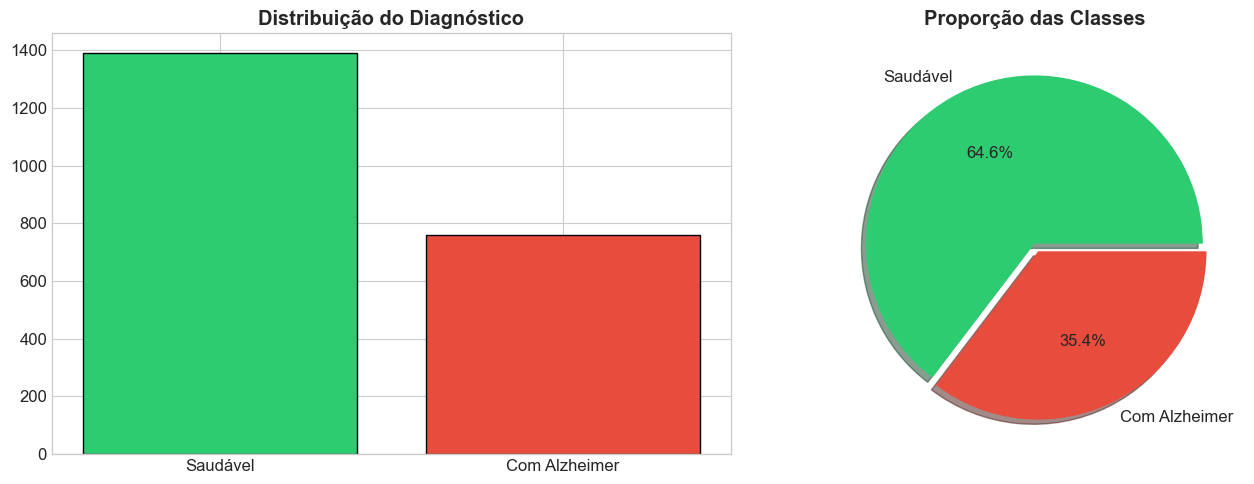

In [5]:
# ==============================================================================
# ANÁLISE DA VARIÁVEL ALVO
# ==============================================================================

contagem_classes = df['Diagnosis'].value_counts()
print("Distribuição da variável alvo:")
print(f"  - Saudável (0): {contagem_classes[0]} ({contagem_classes[0]/len(df)*100:.1f}%)")
print(f"  - Com Alzheimer (1): {contagem_classes[1]} ({contagem_classes[1]/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Saudável', 'Com Alzheimer'], 
            [contagem_classes[0], contagem_classes[1]], 
            color=colors, edgecolor='black')
axes[0].set_title('Distribuição do Diagnóstico', fontweight='bold')

axes[1].pie([contagem_classes[0], contagem_classes[1]], 
            labels=['Saudável', 'Com Alzheimer'],
            autopct='%1.1f%%', colors=colors, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.tight_layout()
plt.savefig('rf_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Balanceamento e Preparação dos Dados

In [6]:
# ==============================================================================
# SEPARAÇÃO E BALANCEAMENTO
# ==============================================================================

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"Após SMOTE: {len(y_balanced)} amostras")
print(f"  - Classe 0: {sum(y_balanced == 0)}")
print(f"  - Classe 1: {sum(y_balanced == 1)}")

Após SMOTE: 2778 amostras
  - Classe 0: 1389
  - Classe 1: 1389


In [7]:
# ==============================================================================
# DIVISÃO TREINO/TESTE
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_balanced
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

feature_names = X.columns.tolist()

Treino: 2083 amostras
Teste: 695 amostras


## 6. Modelo Random Forest Base

In [8]:
# ==============================================================================
# MODELO BASE (100 ÁRVORES, PARÂMETROS PADRÃO)
# ==============================================================================

print("=" * 60)
print("MODELO RANDOM FOREST BASE")
print("=" * 60)

rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f"\nResultados do Modelo Base (100 árvores):")
print(f"  Acurácia:  {acc_base*100:.2f}%")
print(f"  Precisão:  {prec_base*100:.2f}%")
print(f"  Recall:    {rec_base*100:.2f}%")
print(f"  F1-Score:  {f1_base*100:.2f}%")

MODELO RANDOM FOREST BASE

Resultados do Modelo Base (100 árvores):
  Acurácia:  91.22%
  Precisão:  95.25%
  Recall:    86.74%
  F1-Score:  90.80%


## 7. Encontrando o Número Ideal de Árvores

BUSCANDO O NÚMERO IDEAL DE ÁRVORES
  n_estimators= 10: F1-Score = 87.16%
  n_estimators= 25: F1-Score = 89.62%
  n_estimators= 50: F1-Score = 89.91%
  n_estimators= 75: F1-Score = 90.74%
  n_estimators=100: F1-Score = 90.80%
  n_estimators=150: F1-Score = 91.07%
  n_estimators=200: F1-Score = 91.40%
  n_estimators=300: F1-Score = 91.35%
  n_estimators=500: F1-Score = 91.38%

Melhor número de árvores: 200


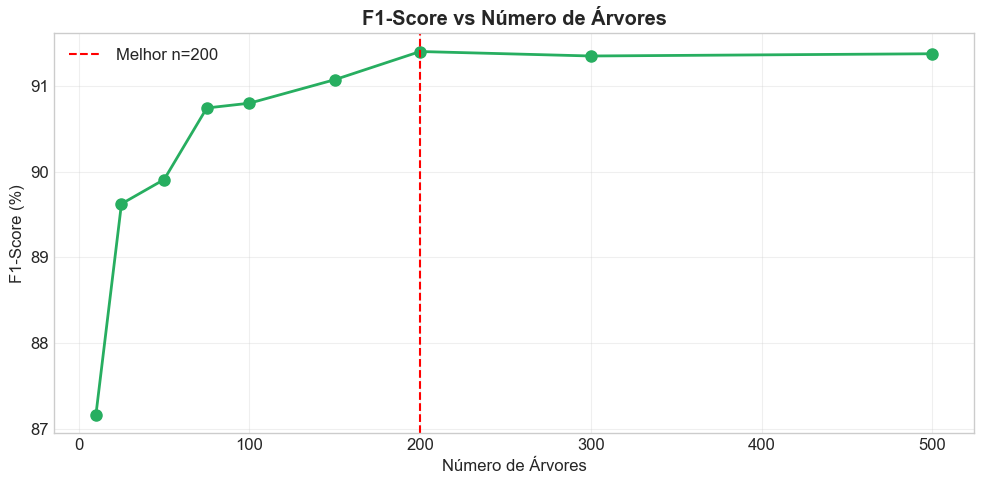

In [9]:
# ==============================================================================
# ENCONTRANDO O NÚMERO IDEAL DE ÁRVORES
# ==============================================================================

print("=" * 60)
print("BUSCANDO O NÚMERO IDEAL DE ÁRVORES")
print("=" * 60)

n_estimators_range = [10, 25, 50, 75, 100, 150, 200, 300, 500]
scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    score = f1_score(y_test, rf.predict(X_test))
    scores.append(score)
    print(f"  n_estimators={n:3d}: F1-Score = {score*100:.2f}%")

best_n = n_estimators_range[np.argmax(scores)]
print(f"\nMelhor número de árvores: {best_n}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, [s*100 for s in scores], 'o-', color='#27ae60', linewidth=2, markersize=8)
plt.axvline(x=best_n, color='red', linestyle='--', label=f'Melhor n={best_n}')
plt.xlabel('Número de Árvores', fontsize=12)
plt.ylabel('F1-Score (%)', fontsize=12)
plt.title('F1-Score vs Número de Árvores', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_melhor_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. GridSearch para Otimização Completa

In [10]:
# ==============================================================================
# GRIDSEARCH PARA OTIMIZAÇÃO
# ==============================================================================

print("=" * 60)
print("GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("=" * 60)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("\nGrade de hiperparâmetros:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\nExecutando GridSearch (pode demorar alguns minutos)...")
grid_search.fit(X_train, y_train)

print(f"\n" + "=" * 60)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS:")
print("=" * 60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-Score (CV): {grid_search.best_score_*100:.2f}%")

GRIDSEARCH - OTIMIZAÇÃO DE HIPERPARÂMETROS

Grade de hiperparâmetros:
  n_estimators: [100, 200, 300]
  max_depth: [5, 10, 15, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Executando GridSearch (pode demorar alguns minutos)...
Fitting 5 folds for each of 270 candidates, totalling 1350 fits

MELHORES HIPERPARÂMETROS ENCONTRADOS:
  max_depth: 10
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Melhor F1-Score (CV): 90.54%


## 9. Modelo Final Otimizado

In [11]:
# ==============================================================================
# MODELO FINAL OTIMIZADO
# ==============================================================================

print("=" * 60)
print("AVALIAÇÃO DO MODELO RANDOM FOREST OTIMIZADO")
print("=" * 60)

rf_otimizado = grid_search.best_estimator_

y_pred = rf_otimizado.predict(X_test)
y_proba = rf_otimizado.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMétricas no Conjunto de Teste:")
print(f"  Acurácia:  {accuracy*100:.2f}%")
print(f"  Precisão:  {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1-Score:  {f1*100:.2f}%")

print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Saudável', 'Alzheimer']))

AVALIAÇÃO DO MODELO RANDOM FOREST OTIMIZADO

Métricas no Conjunto de Teste:
  Acurácia:  91.37%
  Precisão:  96.44%
  Recall:    85.88%
  F1-Score:  90.85%

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
              precision    recall  f1-score   support

    Saudável       0.87      0.97      0.92       348
   Alzheimer       0.96      0.86      0.91       347

    accuracy                           0.91       695
   macro avg       0.92      0.91      0.91       695
weighted avg       0.92      0.91      0.91       695



## 10. Comparação: Base vs Otimizado

COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO

Métrica         Base (100 árv.)      Otimizado            Melhoria       
----------------------------------------------------------------------
Acurácia                    91.22%             91.37%        +0.14%
Precisão                    95.25%             96.44%        +1.19%
Recall                      86.74%             85.88%        -0.86%
F1-Score                    90.80%             90.85%        +0.05%


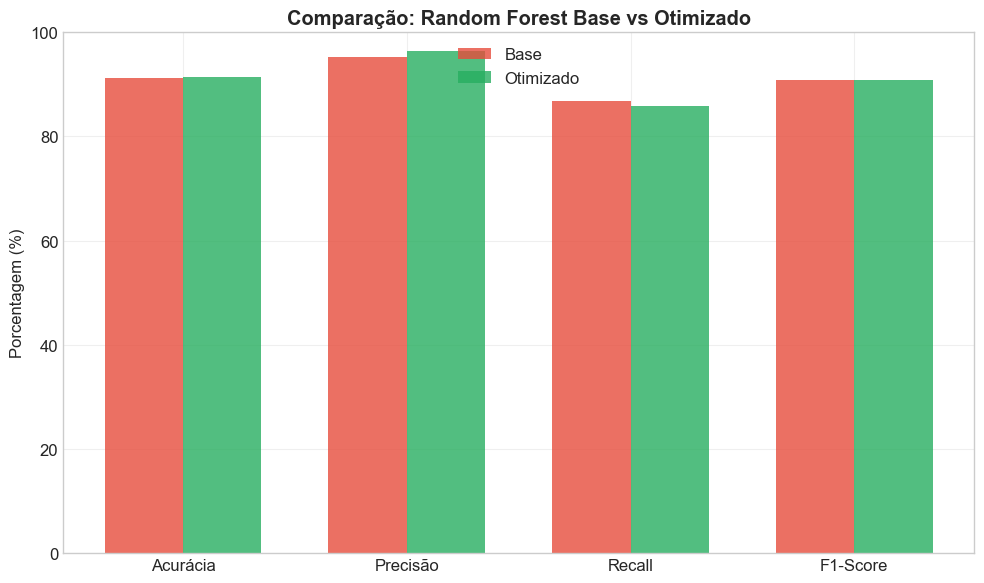

In [12]:
# ==============================================================================
# COMPARAÇÃO BASE vs OTIMIZADO
# ==============================================================================

print("=" * 70)
print("COMPARAÇÃO: MODELO BASE vs MODELO OTIMIZADO")
print("=" * 70)

print(f"\n{'Métrica':<15} {'Base (100 árv.)':<20} {'Otimizado':<20} {'Melhoria':<15}")
print("-" * 70)
print(f"{'Acurácia':<15} {acc_base*100:>17.2f}% {accuracy*100:>17.2f}% {(accuracy-acc_base)*100:>+12.2f}%")
print(f"{'Precisão':<15} {prec_base*100:>17.2f}% {precision*100:>17.2f}% {(precision-prec_base)*100:>+12.2f}%")
print(f"{'Recall':<15} {rec_base*100:>17.2f}% {recall*100:>17.2f}% {(recall-rec_base)*100:>+12.2f}%")
print(f"{'F1-Score':<15} {f1_base*100:>17.2f}% {f1*100:>17.2f}% {(f1-f1_base)*100:>+12.2f}%")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_base = [acc_base*100, prec_base*100, rec_base*100, f1_base*100]
valores_otim = [accuracy*100, precision*100, recall*100, f1*100]

x = np.arange(len(metricas))
width = 0.35

bars1 = ax.bar(x - width/2, valores_base, width, label='Base', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, valores_otim, width, label='Otimizado', color='#27ae60', alpha=0.8)

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Comparação: Random Forest Base vs Otimizado', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_comparacao_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Importância das Features

IMPORTÂNCIA DAS FEATURES (RANDOM FOREST)
   1. FunctionalAssessment          : 18.91%
   2. ADL                           : 17.20%
   3. MMSE                          : 14.75%
   4. MemoryComplaints              : 5.02%
   5. CholesterolTriglycerides      : 3.00%
   6. SleepQuality                  : 2.90%
   7. CholesterolHDL                : 2.89%
   8. PhysicalActivity              : 2.84%
   9. AlcoholConsumption            : 2.74%
  10. DietQuality                   : 2.66%
  11. BMI                           : 2.66%
  12. CholesterolLDL                : 2.47%
  13. CholesterolTotal              : 2.44%
  14. BehavioralProblems            : 2.43%
  15. DiastolicBP                   : 2.30%


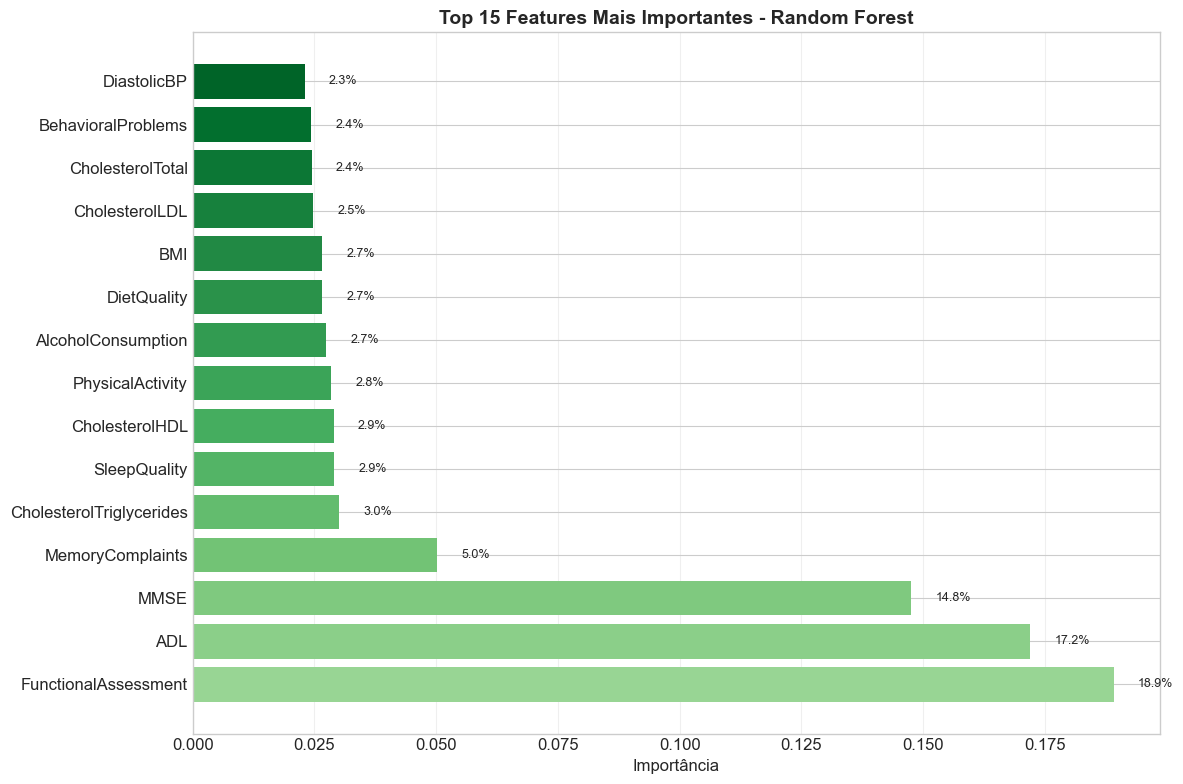

In [13]:
# ==============================================================================
# IMPORTÂNCIA DAS FEATURES
# ==============================================================================

importances = rf_otimizado.feature_importances_
indices = np.argsort(importances)[::-1]

print("=" * 60)
print("IMPORTÂNCIA DAS FEATURES (RANDOM FOREST)")
print("=" * 60)

for i, idx in enumerate(indices[:15], 1):
    print(f"  {i:2d}. {feature_names[idx]:30s}: {importances[idx]*100:.2f}%")

# Gráfico
plt.figure(figsize=(12, 8))
top_n = 15
top_indices = indices[:top_n]

colors = plt.cm.Greens(np.linspace(0.4, 0.9, top_n))[::-1]

bars = plt.barh(range(top_n), importances[top_indices][::-1], color=colors)
plt.yticks(range(top_n), [feature_names[i] for i in top_indices[::-1]])
plt.xlabel('Importância', fontsize=12)
plt.title('Top 15 Features Mais Importantes - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{importances[top_indices[::-1][i]]*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('rf_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Out-of-Bag (OOB) Error

Uma vantagem única do Random Forest é o **OOB Error**, que fornece uma estimativa do erro de generalização sem precisar de um conjunto de validação separado.

In [14]:
# ==============================================================================
# OUT-OF-BAG (OOB) ERROR
# ==============================================================================

print("=" * 60)
print("OUT-OF-BAG (OOB) SCORE")
print("=" * 60)

# Treinando modelo com OOB
rf_oob = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=True  # Habilita OOB
)
rf_oob.fit(X_train, y_train)

print(f"\nOOB Score: {rf_oob.oob_score_*100:.2f}%")
print(f"Acurácia no Teste: {accuracy*100:.2f}%")
print(f"\nO OOB Score é uma boa estimativa do desempenho de generalização.")
print(f"Diferença OOB vs Teste: {abs(rf_oob.oob_score_ - accuracy)*100:.2f}%")

OUT-OF-BAG (OOB) SCORE

OOB Score: 90.69%
Acurácia no Teste: 91.37%

O OOB Score é uma boa estimativa do desempenho de generalização.
Diferença OOB vs Teste: 0.68%


## 13. Matriz de Confusão e Curvas

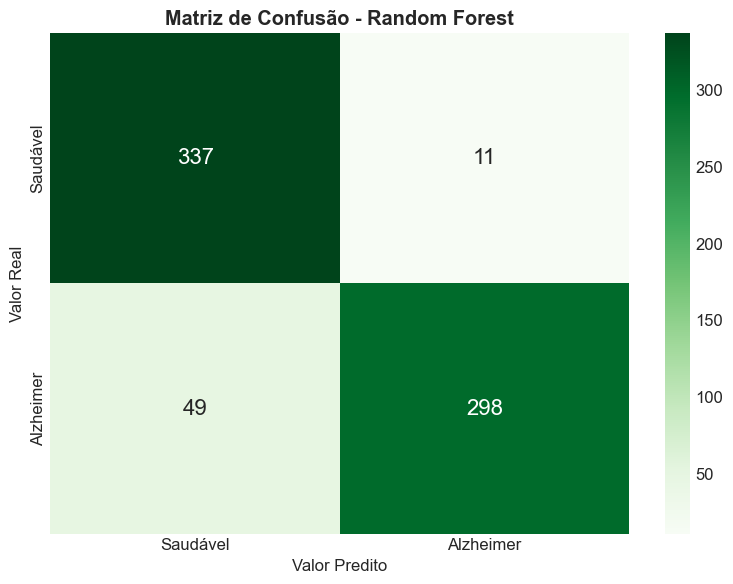

TN: 337, TP: 298, FP: 11, FN: 49


In [15]:
# ==============================================================================
# MATRIZ DE CONFUSÃO
# ==============================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Saudável', 'Alzheimer'],
            yticklabels=['Saudável', 'Alzheimer'],
            annot_kws={'size': 16})
plt.title('Matriz de Confusão - Random Forest', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.tight_layout()
plt.savefig('rf_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}, TP: {tp}, FP: {fp}, FN: {fn}")

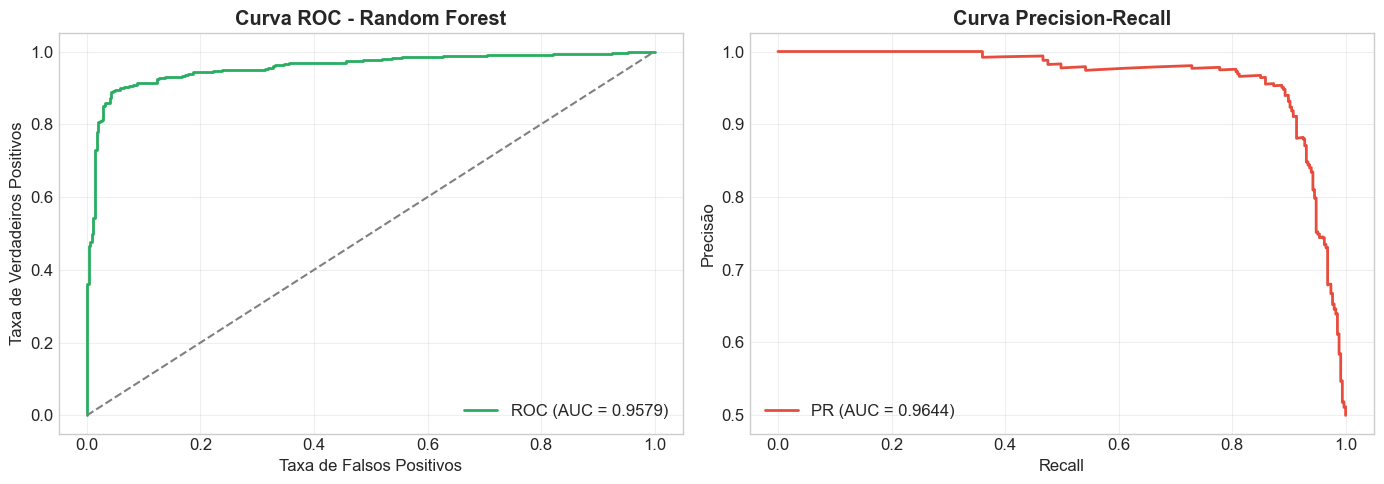

AUC-ROC: 0.9579
AUC-PR: 0.9644


In [16]:
# ==============================================================================
# CURVAS ROC E PRECISION-RECALL
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#27ae60', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('Curva ROC - Random Forest', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_curve, precision_curve)

axes[1].plot(recall_curve, precision_curve, color='#e74c3c', lw=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")
print(f"AUC-PR: {pr_auc:.4f}")

## 14. Conclusão

In [17]:
# ==============================================================================
# RESUMO FINAL
# ==============================================================================

print("=" * 70)
print("RESUMO FINAL - RANDOM FOREST PARA DETECÇÃO DE ALZHEIMER")
print("=" * 70)

print(f"\nMelhores Hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nDesempenho Final:")
print(f"  - Acurácia:  {accuracy*100:.2f}%")
print(f"  - Precisão:  {precision*100:.2f}%")
print(f"  - Recall:    {recall*100:.2f}%")
print(f"  - F1-Score:  {f1*100:.2f}%")
print(f"  - AUC-ROC:   {roc_auc:.4f}")

print(f"\nTop 5 Features Mais Importantes:")
for i, idx in enumerate(indices[:5], 1):
    print(f"  {i}. {feature_names[idx]} ({importances[idx]*100:.1f}%)")

print("\n" + "=" * 70)
print("VANTAGENS DO RANDOM FOREST:")
print("=" * 70)
print("""
  1. ROBUSTEZ: Menos sensível a overfitting que uma única árvore
  2. PERFORMANCE: Geralmente alta acurácia out-of-the-box
  3. IMPORTÂNCIA DE FEATURES: Identifica variáveis relevantes
  4. OOB ERROR: Estimativa de erro sem validação separada
  5. PARALELIZÁVEL: Treino rápido com múltiplos núcleos
  6. NÃO REQUER NORMALIZAÇÃO: Insensível à escala
""")

print("LIMITAÇÕES:")
print("""
  1. MENOS INTERPRETÁVEL: Difícil visualizar o modelo completo
  2. MEMÓRIA: Muitas árvores consomem mais recursos
  3. LENTO PARA PREDIÇÃO: Precisa consultar todas as árvores
  4. VIÉS EM DADOS DESBALANCEADOS: Pode favorecer classe majoritária
""")

RESUMO FINAL - RANDOM FOREST PARA DETECÇÃO DE ALZHEIMER

Melhores Hiperparâmetros:
  - max_depth: 10
  - max_features: sqrt
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 300

Desempenho Final:
  - Acurácia:  91.37%
  - Precisão:  96.44%
  - Recall:    85.88%
  - F1-Score:  90.85%
  - AUC-ROC:   0.9579

Top 5 Features Mais Importantes:
  1. FunctionalAssessment (18.9%)
  2. ADL (17.2%)
  3. MMSE (14.8%)
  4. MemoryComplaints (5.0%)
  5. CholesterolTriglycerides (3.0%)

VANTAGENS DO RANDOM FOREST:

  1. ROBUSTEZ: Menos sensível a overfitting que uma única árvore
  2. PERFORMANCE: Geralmente alta acurácia out-of-the-box
  3. IMPORTÂNCIA DE FEATURES: Identifica variáveis relevantes
  4. OOB ERROR: Estimativa de erro sem validação separada
  5. PARALELIZÁVEL: Treino rápido com múltiplos núcleos
  6. NÃO REQUER NORMALIZAÇÃO: Insensível à escala

LIMITAÇÕES:

  1. MENOS INTERPRETÁVEL: Difícil visualizar o modelo completo
  2. MEMÓRIA: Muitas árvores consomem mais recursos